# Systeme d'alerte tempete - prediction de l'etat d'un arbre

## Objectif
Construire un modele simple et explicable pour predire `fk_arb_etat` a partir des caracteristiques d'un arbre.

## Choix methodologiques
- pretraitement simple et separe en etapes claires
- comparaison entre deux modeles standards de scikit-learn
- choix final justifie a partir des resultats
- pas de normalisation, car le modele final retenu est base sur des arbres
- ordre de traitement respecte pour eviter la data leakage :
  1. separation train / test
  2. apprentissage du pretraitement sur `X_train` uniquement
  3. transformation de `X_train` et `X_test`
  4. entrainement des modeles

## Remarque metier
Le besoin metier porte sur le risque de chute pendant une tempete. Ici, on conserve la cible d'origine `fk_arb_etat` pour rester fidele aux donnees et eviter de construire une regle binaire arbitraire sans validation metier.
Une relecture metier simple est toutefois ajoutee a la fin du notebook :
- `EN PLACE` = arbre stable
- autres classes = arbre pouvant necessiter une intervention


In [52]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier


## 1. Chargement des donnees
On charge le fichier CSV en cherchant le chemin le plus probable selon l'endroit depuis lequel le notebook est execute.

In [53]:
data_candidates = [Path('../Données_V4.csv'), Path('Données_V4.csv')]

DATA_PATH = None
for candidate in data_candidates:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError('Le fichier Données_V4.csv est introuvable.')

print(f'Fichier utilise : {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH, sep=';')
print('Dimensions du jeu de donnees :', df.shape)
df.head()


Fichier utilise : /Users/gauthiercivilise/Documents/CIPA4/Projet_IA_WEB_DATA/projet-big-data-ia-web/Données_V4.csv
Dimensions du jeu de donnees : (11248, 36)


,X,Y,OBJECTID,created_date,created_user,src_geo,clc_quartier,clc_secteur,haut_tot,haut_tronc,...,villeca,nomfrancais,nomlatin,GlobalID,CreationDate,Creator,EditDate,Editor,feuillage,remarquable
0,1.720320e+06,8.294619e+06,1,02/02/2017,mickael.delaere,Orthophoto,Quartier du Centre-Ville,Boulevard Richelieu,0.0,0.0,...,Ville,RAS,RAS,{476EB2CE-1FD4-4F89-8162-79D75651225A},15/01/2018,mickael.delaere,15/01/2018,mickael.delaere,NaN,Non
1,1.720898e+06,8.293531e+06,2,02/02/2017,mickael.delaere,Orthophoto,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,...,Ville,RAS,RAS,{B5A9F630-92C5-4B8A-A934-0CABDA46085E},15/01/2018,mickael.delaere,15/01/2018,mickael.delaere,NaN,Non
2,1.720894e+06,8.293542e+06,3,02/02/2017,mickael.delaere,Orthophoto,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,...,Ville,RAS,RAS,{F5914EAD-05CD-4ADF-A7C9-55EFF91B2ABE},15/01/2018,mickael.delaere,15/01/2018,mickael.delaere,NaN,Non
3,1.720902e+06,8.293545e+06,4,02/02/2017,mickael.delaere,Orthophoto,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,...,Ville,RAS,RAS,{41168E06-B7C0-43CD-B8FE-7495B6E93AB5},15/01/2018,mickael.delaere,15/01/2018,mickael.delaere,NaN,Non
4,1.721089e+06,8.293619e+06,5,02/02/2017,mickael.delaere,Orthophoto,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,...,Ville,RAS,RAS,{4F0E4B12-4612-4F61-9911-43684831FD7D},15/01/2018,mickael.delaere,15/01/2018,mickael.delaere,NaN,Non


## 2. Selection des colonnes utiles
On ne garde que des variables simples a expliquer pour la prediction :
- position de l'arbre
- dimensions
- contexte d'implantation
- quelques caracteristiques descriptives

La cible a predire est `fk_arb_etat`.

In [54]:
feature_columns = [
    'X',
    'Y',
    'clc_quartier',
    'clc_secteur',
    'haut_tot',
    'haut_tronc',
    'tronc_diam',
    'fk_stadedev',
    'fk_port',
    'fk_pied',
    'fk_situation',
    'fk_revetement',
    'age_estim',
    'villeca',
    'feuillage',
    'remarquable',
]

target_column = 'fk_arb_etat'

feature_columns = [column for column in feature_columns if column in df.columns]

df_model = df[feature_columns + [target_column]].copy()
print('Colonnes retenues :', feature_columns)
print('Dimensions apres selection :', df_model.shape)

df_model.head()


Colonnes retenues : ['X', 'Y', 'clc_quartier', 'clc_secteur', 'haut_tot', 'haut_tronc', 'tronc_diam', 'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'age_estim', 'villeca', 'feuillage', 'remarquable']
Dimensions apres selection : (11248, 17)


,X,Y,clc_quartier,clc_secteur,haut_tot,haut_tronc,tronc_diam,fk_stadedev,fk_port,fk_pied,fk_situation,fk_revetement,age_estim,villeca,feuillage,remarquable,fk_arb_etat
0,1.720320e+06,8.294619e+06,Quartier du Centre-Ville,Boulevard Richelieu,0.0,0.0,0.0,NaN,NaN,NaN,Alignement,NaN,0.0,Ville,NaN,Non,ABATTU
1,1.720898e+06,8.293531e+06,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,0.0,NaN,NaN,NaN,Alignement,NaN,0.0,Ville,NaN,Non,ABATTU
2,1.720894e+06,8.293542e+06,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,0.0,NaN,NaN,NaN,Alignement,NaN,0.0,Ville,NaN,Non,ABATTU
3,1.720902e+06,8.293545e+06,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,0.0,NaN,NaN,NaN,Alignement,NaN,0.0,Ville,NaN,Non,ABATTU
4,1.721089e+06,8.293619e+06,Quartier du Centre-Ville,Boulevard Léon Blum,0.0,0.0,0.0,NaN,NaN,NaN,Alignement,NaN,0.0,Ville,NaN,Non,ABATTU


## 3. Verification des valeurs manquantes et de la cible
Avant l'apprentissage, on verifie les valeurs manquantes. Les valeurs manquantes de la cible ne peuvent pas etre apprises, donc elles sont retirees.

On observe aussi la repartition des classes, car un desequilibre peut rendre l'accuracy trompeuse. Dans ce cas, il faut regarder aussi le `f1-score` et surtout le `recall` des classes rares.

In [55]:
missing_values = df_model.isna().sum().sort_values(ascending=False)
print('Valeurs manquantes par colonne :')
print(missing_values[missing_values > 0])

print('Repartition de la cible :')
print(df_model[target_column].value_counts(dropna=False))

df_model = df_model.dropna(subset=[target_column]).copy()
print('Dimensions apres suppression des cibles manquantes :', df_model.shape)


Valeurs manquantes par colonne :
fk_revetement    967
age_estim        833
haut_tronc       715
clc_quartier     492
feuillage        194
fk_stadedev      170
fk_port          157
fk_pied          131
villeca          102
haut_tot          55
tronc_diam        26
remarquable       18
fk_situation      17
clc_secteur       14
fk_arb_etat        9
dtype: int64
Repartition de la cible :
fk_arb_etat
EN PLACE    10221
ABATTU        624
ESSOUCHE      206
REMPLACÉ      188
NaN             9
Name: count, dtype: int64
Dimensions apres suppression des cibles manquantes : (11239, 17)


## 4. Separation train / test
Cette etape est faite avant le pretraitement pour eviter la fuite de donnees.

C'est un point important a justifier a l'oral :
- le test ne doit jamais influencer l'encodage
- le test ne doit jamais influencer l'imputation
- le test ne doit jamais influencer le choix du modele

In [56]:
X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Taille train :', X_train.shape)
print('Taille test :', X_test.shape)


Taille train : (8991, 16)
Taille test : (2248, 16)


## 5. Pretraitement simple et explicable
Le pretraitement est volontairement separe en etapes claires :
- colonnes numeriques : imputation par la mediane
- colonnes categorielles : imputation par la modalite la plus frequente
- encodage One-Hot des colonnes categorielles

On apprend ces objets uniquement sur `X_train`, puis on applique la transformation a `X_train` et `X_test`.

On sauvegarde ensuite les objets utiles avec `joblib` pour pouvoir reutiliser exactement le meme pretraitement dans le script de prediction.

In [57]:
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_columns = [column for column in feature_columns if column not in categorical_columns]

print('Colonnes categorielles :', categorical_columns)
print('Colonnes numeriques :', numerical_columns)

categorical_imputer = SimpleImputer(strategy='most_frequent')
numerical_imputer = SimpleImputer(strategy='median')
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = categorical_imputer.fit_transform(X_train[categorical_columns])
X_test_cat = categorical_imputer.transform(X_test[categorical_columns])

X_train_num = numerical_imputer.fit_transform(X_train[numerical_columns])
X_test_num = numerical_imputer.transform(X_test[numerical_columns])

X_train_cat_encoded = onehot_encoder.fit_transform(X_train_cat)
X_test_cat_encoded = onehot_encoder.transform(X_test_cat)

X_train_ready = np.hstack([X_train_num, X_train_cat_encoded])
X_test_ready = np.hstack([X_test_num, X_test_cat_encoded])

print('Shape train apres pretraitement :', X_train_ready.shape)
print('Shape test apres pretraitement :', X_test_ready.shape)

preprocessor_dir = Path('preprocessors')
preprocessor_dir.mkdir(exist_ok=True)

joblib.dump(onehot_encoder, preprocessor_dir / 'onehot_encoder.joblib')
joblib.dump(categorical_imputer, preprocessor_dir / 'categorical_imputer.joblib')
joblib.dump(numerical_imputer, preprocessor_dir / 'numerical_imputer.joblib')
joblib.dump(feature_columns, preprocessor_dir / 'feature_columns.joblib')
joblib.dump(categorical_columns, preprocessor_dir / 'categorical_columns.joblib')
joblib.dump(numerical_columns, preprocessor_dir / 'numerical_columns.joblib')

print('Objets de pretraitement sauvegardes dans le dossier preprocessors/.')


Colonnes categorielles : ['clc_quartier', 'clc_secteur', 'fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation', 'fk_revetement', 'villeca', 'feuillage', 'remarquable']
Colonnes numeriques : ['X', 'Y', 'haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim']
Shape train apres pretraitement : (8991, 357)
Shape test apres pretraitement : (2248, 357)
Objets de pretraitement sauvegardes dans le dossier preprocessors/.


## 6. Faut-il normaliser les variables ?
Ici, la reponse est non.

Pourquoi ?
- un arbre de decision et une foret aleatoire se basent sur des decoupages successifs des variables
- ces modeles ne sont pas sensibles a l'echelle des variables comme peuvent l'etre une regression logistique ou un KNN
- ajouter une normalisation compliquerait le notebook sans gain pedagogique clair

Ce choix est donc simple, classique et facile a defendre.

## 7. Comparaison de deux modeles
Pour justifier le choix final, on compare deux modeles standards et faciles a expliquer :
- `DecisionTreeClassifier` : modele de base tres interpretable
- `RandomForestClassifier` : ensemble de plusieurs arbres, generalement plus robuste

L'idee est de montrer si l'ajout de plusieurs arbres apporte un vrai gain par rapport a un arbre seul.

In [58]:
decision_tree_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
}

random_forest_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

models_to_compare = {
    'DecisionTree': GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=42),
        param_grid=decision_tree_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=1,
    ),
    'RandomForest': GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=random_forest_grid,
        cv=5,
        scoring='f1_weighted',
        n_jobs=1,
    ),
}

comparison_results = []
trained_models = {}
predictions = {}

for model_name, model in models_to_compare.items():
    model.fit(X_train_ready, y_train)
    y_pred = model.predict(X_test_ready)

    trained_models[model_name] = model
    predictions[model_name] = y_pred

    comparison_results.append({
        'modele': model_name,
        'meilleurs_parametres': model.best_params_,
        'accuracy_test': round(accuracy_score(y_test, y_pred), 4),
        'f1_weighted_test': round(f1_score(y_test, y_pred, average='weighted'), 4),
    })

comparison_df = pd.DataFrame(comparison_results).sort_values(
    by='f1_weighted_test',
    ascending=False,
).reset_index(drop=True)

comparison_df


,modele,meilleurs_parametres,accuracy_test,f1_weighted_test
0,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.9533,0.9480
1,DecisionTree,"{'max_depth': 20, 'min_samples_split': 5}",0.9440,0.9383


## 8. Choix du modele final
Le modele retenu est celui qui obtient les meilleurs resultats globaux sur le jeu de test.

Ici, la foret aleatoire fait mieux qu'un arbre seul, car elle limite le surapprentissage.

In [59]:
selected_model_name = comparison_df.loc[0, 'modele']
selected_search = trained_models[selected_model_name]
best_model = selected_search.best_estimator_
y_pred = predictions[selected_model_name]

print('Modele retenu :', selected_model_name)
print('Meilleurs parametres :', selected_search.best_params_)
print('Tableau comparatif :')
print(comparison_df)


Modele retenu : RandomForest
Meilleurs parametres : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tableau comparatif :
         modele                               meilleurs_parametres  \
0  RandomForest  {'max_depth': None, 'min_samples_split': 2, 'n...   
1  DecisionTree          {'max_depth': 20, 'min_samples_split': 5}   

   accuracy_test  f1_weighted_test  
0         0.9533            0.9480  
1         0.9440            0.9383  


## 9. Evaluation detaillee du modele retenu
On conserve les indicateurs demandes :
- `accuracy`
- `f1-score`
- `classification_report`
- matrice de confusion

Comme les classes sont desequilibrees, on ne se contente pas de l'accuracy. Une bonne accuracy peut masquer de mauvaises performances sur les classes rares.

On ajoute aussi une lecture metier simple :
- `EN PLACE` = stable
- autres classes = a surveiller / intervention possible

Cela permet d'insister sur le `recall` des cas a risque.

Accuracy : 0.9533
F1-score weighted : 0.948
Classification report multiclasses :
              precision    recall  f1-score   support

      ABATTU       0.85      0.61      0.71       125
    EN PLACE       0.96      0.99      0.98      2044
    ESSOUCHE       0.81      0.41      0.55        41
    REMPLACÉ       0.86      0.50      0.63        38

    accuracy                           0.95      2248
   macro avg       0.87      0.63      0.72      2248
weighted avg       0.95      0.95      0.95      2248



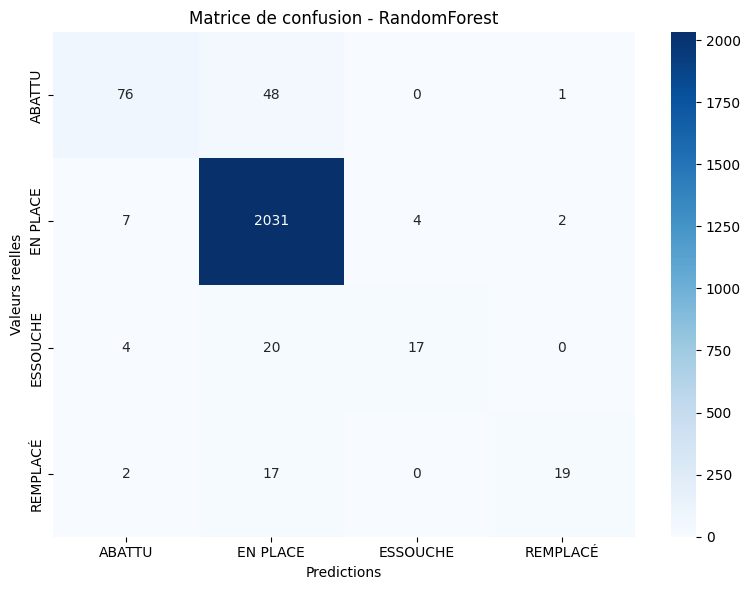

Classification report metier (stable / risque) :
              precision    recall  f1-score   support

      risque       0.90      0.58      0.71       204
      stable       0.96      0.99      0.98      2044

    accuracy                           0.96      2248
   macro avg       0.93      0.79      0.84      2248
weighted avg       0.95      0.96      0.95      2248



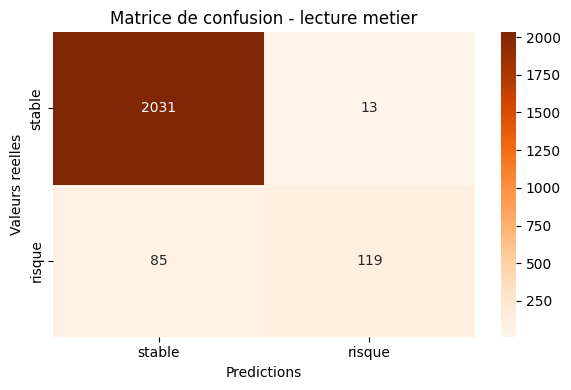

In [60]:
print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('F1-score weighted :', round(f1_score(y_test, y_pred, average='weighted'), 4))
print('Classification report multiclasses :')
print(classification_report(y_test, y_pred))

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Matrice de confusion - {selected_model_name}')
plt.xlabel('Predictions')
plt.ylabel('Valeurs reelles')
plt.tight_layout()
plt.show()

# Relecture metier binaire pour insister sur la detection des arbres a risque.
y_test_business = np.where(y_test == 'EN PLACE', 'stable', 'risque')
y_pred_business = np.where(y_pred == 'EN PLACE', 'stable', 'risque')

print('Classification report metier (stable / risque) :')
print(classification_report(y_test_business, y_pred_business))

cm_business = confusion_matrix(
    y_test_business,
    y_pred_business,
    labels=['stable', 'risque'],
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_business,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['stable', 'risque'],
    yticklabels=['stable', 'risque'],
)
plt.title('Matrice de confusion - lecture metier')
plt.xlabel('Predictions')
plt.ylabel('Valeurs reelles')
plt.tight_layout()
plt.show()


## 10. Justification du choix final
Si `RandomForest` arrive en tete, le choix est facile a justifier :
- il obtient de meilleurs scores que l'arbre de decision seul
- il reste simple a expliquer, car il repose sur le meme principe de base qu'un arbre
- il est plus robuste et generalise mieux
- il gere mieux la variabilite des donnees et limite le surapprentissage

Cette comparaison permet donc de montrer que le choix final n'est pas arbitraire.

## 11. Sauvegarde du modele final
On sauvegarde le meilleur modele retenu pour le recharger plus tard dans `predict_tempete.py` sans relancer l'entrainement.

In [61]:
model_dir = Path('models')
model_dir.mkdir(exist_ok=True)

model_path = model_dir / 'random_forest_tempete.joblib'
joblib.dump(best_model, model_path)

print(f'Modele sauvegarde : {model_path}')


Modele sauvegarde : models/random_forest_tempete.joblib


## 12. Conclusion
Le notebook respecte les consignes du sujet et ajoute maintenant une vraie comparaison entre deux modeles :
- selection simple des variables
- controle des valeurs manquantes
- `train_test_split` avant le pretraitement
- `OneHotEncoder` pour les colonnes categorielles
- comparaison entre `DecisionTreeClassifier` et `RandomForestClassifier`
- justification du choix du modele final
- sauvegarde des objets de pretraitement et du modele final
- lecture metier centree sur le rappel des arbres potentiellement a risque